<a href="https://colab.research.google.com/github/JagadishPrasannaTA/Blood-Group-Detection-Using-Fingerprint-/blob/main/Finger_print.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Streaming output truncated to the last 5000 lines.
Processing: cluster_2_2968.BMP
Processing: cluster_2_4215.BMP
Processing: cluster_2_1053.BMP
Processing: cluster_2_2442.BMP
Processing: cluster_2_2778.BMP
Processing: cluster_2_1125.BMP
Processing: cluster_2_848.BMP
Processing: cluster_2_5188.BMP
Processing: cluster_2_4758.BMP
Processing: cluster_2_140.BMP
Processing: cluster_2_90.BMP
Processing: cluster_2_4249.BMP
Processing: cluster_2_5390.BMP
Processing: cluster_2_5870.BMP
Processing: cluster_2_432.BMP
Processing: cluster_2_5070.BMP
Processing: cluster_2_4194.BMP
Processing: cluster_2_4439.BMP
Processing: cluster_2_2816.BMP
Processing: cluster_2_14.BMP
Processing: cluster_2_5215.BMP
Processing: cluster_2_4935.BMP
Processing: cluster_2_4310.BMP
Processing: cluster_2_758.BMP
Processing: cluster_2_5632.BMP
Processing: cluster_2_5642.BMP
Processing: cluster_2_884.BMP
Processing: cluster_2_4638.BMP
Processing: cluster_2_2040.BMP
Processing: cluster_2_988.BMP
Processing: cluster_2_4678.BM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.2292 - loss: 2.3826 - val_accuracy: 0.7417 - val_loss: 0.9036 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7364 - loss: 0.8934 - val_accuracy: 0.8358 - val_loss: 0.6037 - learning_rate: 9.0000e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8025 - loss: 0.6752 - val_accuracy: 0.8608 - val_loss: 0.5234 - learning_rate: 8.1000e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8366 - loss: 0.5772 - val_accuracy: 0.8633 - val_loss: 0.4655 - learning_rate: 7.2900e-04
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8579 - loss: 0.4991 - val_accuracy: 0.8808 - val_loss: 0.4368 - learning_rate: 6.5610e-04
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8520 - loss: 0.4860 - val_accuracy: 0.8767 - val_loss: 0.4502 - learning_rate: 5.9049e-04
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accurac

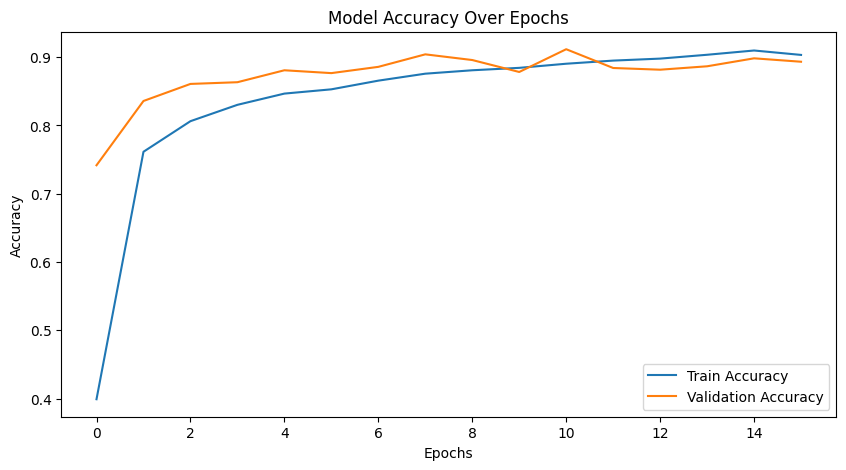

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
import zipfile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Set dataset path
zip_path = "/content/drive/MyDrive/BLOOD_GROUP_PRED/dataset"
extract_path = "/content/dataset"

# Unzipping the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extracted contents
print("Extracted folders:", os.listdir(extract_path))

# Update extract_path if dataset is in a subfolder
extract_path = os.path.join(extract_path, "dataset_blood_group")
print("Subdirectories:", os.listdir(extract_path))

labels = []
features = []
image_size = (128, 128)  # Standard size for CNN input

# Read images from subfolders and extract features
for blood_group in os.listdir(extract_path):
    subfolder_path = os.path.join(extract_path, blood_group)
    if os.path.isdir(subfolder_path):  # Check if it's a directory
        for filename in os.listdir(subfolder_path):
            if filename.lower().endswith((".bmp", ".jpg", ".png")):
                image_path = os.path.join(subfolder_path, filename)
                img = cv2.imread(image_path)
                if img is None:
                    print(f"Error loading image: {image_path}")
                    continue
                img = cv2.resize(img, image_size)  # Resize for uniformity
                img = img / 255.0  # Normalize pixel values
                features.append(img)
                labels.append(blood_group)
                print(f"Processing: {filename}")

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Learning rate scheduler
def scheduler(epoch, lr):
    return lr * 0.9 if epoch > 0 else lr
lr_callback = keras.callbacks.LearningRateScheduler(scheduler)

# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(len(np.unique(y)), activation='softmax')  # Output layer with softmax
])

# Compile model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_callback])

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.show()


MODEL SAVING

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import cv2
import os
import zipfile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Mount Google Drive
#drive.mount('/content/drive', force_remount=True)

# Set dataset path
zip_path = "/content/drive/MyDrive/BLOOD_GROUP_PRED/dataset"  # zip file path
extract_path = "/content/dataset"  # Extract location

# Unzipping the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extracted contents
print("Extracted folders:", os.listdir(extract_path))

# Update extract_path if dataset is in a subfolder
extract_path = os.path.join(extract_path, "dataset_blood_group")  # Update folder name if necessary
print("Subdirectories:", os.listdir(extract_path))

labels = []
features = []
image_size = (128, 128)  # Standard size for CNN input

# Read images from subfolders and extract features
for blood_group in os.listdir(extract_path):
    subfolder_path = os.path.join(extract_path, blood_group)
    if os.path.isdir(subfolder_path):  # Check if it's a directory
        for filename in os.listdir(subfolder_path):
            if filename.lower().endswith((".bmp", ".jpg", ".png")):
                image_path = os.path.join(subfolder_path, filename)
                img = cv2.imread(image_path)
                if img is None:
                    print(f"Error loading image: {image_path}")
                    continue
                img = cv2.resize(img, image_size)  # Resize for uniformity
                img = img / 255.0  # Normalize pixel values
                features.append(img)
                labels.append(blood_group)
                print(f"Processing: {filename}")

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

Streaming output truncated to the last 5000 lines.
Processing: cluster_2_2968.BMP
Processing: cluster_2_4215.BMP
Processing: cluster_2_1053.BMP
Processing: cluster_2_2442.BMP
Processing: cluster_2_2778.BMP
Processing: cluster_2_1125.BMP
Processing: cluster_2_848.BMP
Processing: cluster_2_5188.BMP
Processing: cluster_2_4758.BMP
Processing: cluster_2_140.BMP
Processing: cluster_2_90.BMP
Processing: cluster_2_4249.BMP
Processing: cluster_2_5390.BMP
Processing: cluster_2_5870.BMP
Processing: cluster_2_432.BMP
Processing: cluster_2_5070.BMP
Processing: cluster_2_4194.BMP
Processing: cluster_2_4439.BMP
Processing: cluster_2_2816.BMP
Processing: cluster_2_14.BMP
Processing: cluster_2_5215.BMP
Processing: cluster_2_4935.BMP
Processing: cluster_2_4310.BMP
Processing: cluster_2_758.BMP
Processing: cluster_2_5632.BMP
Processing: cluster_2_5642.BMP
Processing: cluster_2_884.BMP
Processing: cluster_2_4638.BMP
Processing: cluster_2_2040.BMP
Processing: cluster_2_988.BMP
Processing: cluster_2_4678.BM

In [ ]:
# Save model in Google Drive
model.save('/content/drive/My Drive/fp_model.keras')
print("Model Saved Successfully")



Model Saved Successfully


In [ ]:
# Get the mapping of label indices
class_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(class_mapping)


{np.str_('A+'): 0, np.str_('A-'): 1, np.str_('AB+'): 2, np.str_('AB-'): 3, np.str_('B+'): 4, np.str_('B-'): 5, np.str_('O+'): 6, np.str_('O-'): 7}


TESTING THE MODEL

In [ ]:
import tensorflow as tf
import cv2
import numpy as np

# Load the saved model
model = tf.keras.models.load_model('/content/drive/My Drive/fp_model.keras')  # Update with your path

# Load and preprocess an image
image_path = "/content/dataset/dataset_blood_group/AB+/cluster_4_103.BMP"  # Change this to your test image
img = cv2.imread(image_path)
img = cv2.resize(img, (128, 128))  # Resize to match training size
img = img / 255.0  # Normalize (if done during training)
img = np.expand_dims(img, axis=0)  # Add batch dimension


# Make predictions
predictions = model.predict(img)
predicted_class = np.argmax(predictions, axis=1)  # Get the highest probability class


# Mapping of class indices to blood groups
class_mapping = {0: "A+", 1: "A-", 2: "AB+", 3: "AB-", 4: "B+", 5: "B-", 6: "O+", 7: "O-"}

# Get predicted blood group
predicted_blood_group = class_mapping[predicted_class[0]]
print(f"Predicted Blood Group: {predicted_blood_group}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted Blood Group: AB+


In [ ]:
import pickle

# Define the path where you want to save the pickle file
pickle_model_path = '/content/drive/My Drive/fp_model.pkl'

# Save the trained Keras model as a pickle file
with open(pickle_model_path, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully as pickle file: {pickle_model_path}")


Model saved successfully as pickle file: /content/drive/My Drive/fp_model.pkl


In [ ]:
# Load the model back from the pickle file
with open('/content/drive/My Drive/fp_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Verify that the model is loaded correctly
print("Model loaded successfully")

# You can now use `loaded_model` to make predictions or evaluate


Model loaded successfully


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
